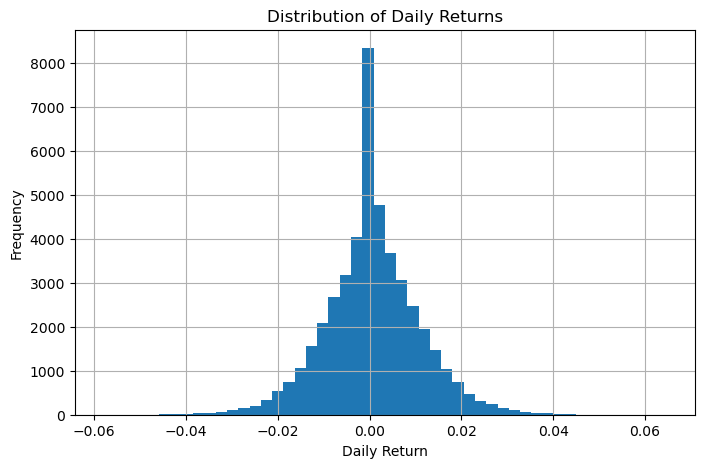

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav["nav"] /
    nav.groupby("amfi_code")["nav"].shift(1)
) - 1

returns = nav[
    ["amfi_code", "date", "daily_return"]
]

returns.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

plt.figure(figsize=(8,5))
nav["daily_return"].hist(
    bins=50
)
plt.title(
    "Distribution of Daily Returns"
)
plt.xlabel(
    "Daily Return"
)
plt.ylabel(
    "Frequency"
)

plt.show()

In [2]:
nav.groupby("amfi_code")["date"].agg(
    ["min", "max"]
).head()

,min,max
amfi_code,,
100016,2022-01-03,2026-05-29
100025,2022-01-03,2026-05-29
100033,2022-01-03,2026-05-29
101206,2022-01-03,2026-05-29
101207,2022-01-03,2026-05-29


In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

latest_date = nav["date"].max()

cagr_data = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    latest_nav = fund_data.iloc[-1]["nav"]

    # 1 Year CAGR
    one_year_data = fund_data[
        fund_data["date"] >= latest_date - pd.DateOffset(years=1)
    ]

    if len(one_year_data) > 0:
        start_nav = one_year_data.iloc[0]["nav"]
        cagr_1y = (
            (latest_nav / start_nav) ** (1/1)
        ) - 1
    else:
        cagr_1y = np.nan

    # 3 Year CAGR
    three_year_data = fund_data[
        fund_data["date"] >= latest_date - pd.DateOffset(years=3)
    ]

    if len(three_year_data) > 0:
        start_nav = three_year_data.iloc[0]["nav"]
        cagr_3y = (
            (latest_nav / start_nav) ** (1/3)
        ) - 1
    else:
        cagr_3y = np.nan

    # Since Available Data CAGR
    start_nav = fund_data.iloc[0]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] -
         fund_data.iloc[0]["date"]).days
    ) / 365

    cagr_since_start = (
        (latest_nav / start_nav) ** (1/years)
    ) - 1

    cagr_data.append([
        fund,
        cagr_1y,
        cagr_3y,
        cagr_since_start
    ])

cagr_report = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr_1y",
        "cagr_3y",
        "cagr_since_start"
    ]
)

cagr_report.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

cagr_report.head()

,amfi_code,cagr_1y,cagr_3y,cagr_since_start
0,100016,-0.022243,0.012926,0.026352
1,100025,0.037050,0.039164,0.044551
2,100033,0.532324,0.324425,0.300997
3,101206,0.479241,0.289677,0.235205
4,101207,-0.239860,-0.041524,0.079331


In [4]:
cagr_report.sort_values(
    "cagr_3y",
    ascending=False
).head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_since_start
16,119094,0.222611,0.351118,0.281926
34,148567,0.203607,0.340009,0.309499
24,120504,0.130643,0.324874,0.232774
2,100033,0.532324,0.324425,0.300997
25,120505,0.296047,0.317775,0.328016
19,119551,0.604373,0.304565,0.257849
30,120843,0.266571,0.295828,0.308833
36,148569,0.397518,0.291789,0.319245
3,101206,0.479241,0.289677,0.235205
39,149324,0.651387,0.270004,0.322621


In [5]:
cagr_report.sort_values(
    "cagr_3y"
).head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_since_start
17,119095,-0.427976,-0.117058,0.015205
4,101207,-0.239860,-0.041524,0.079331
22,119599,0.139478,-0.013374,0.020531
7,102886,-0.167975,-0.007674,0.011709
14,119092,0.016091,0.005259,0.063635
0,100016,-0.022243,0.012926,0.026352
1,100025,0.037050,0.039164,0.044551
13,118636,0.104549,0.040622,0.053132
18,119120,0.055220,0.058404,0.058853
5,101208,0.072366,0.063158,0.065044


In [6]:
import pandas as pd
import numpy as np

returns = pd.read_csv(
    "../data/processed/returns_computed.csv"
)

rf = 0.065

sharpe_data = []

for fund in returns["amfi_code"].unique():

    fund_returns = returns[
        returns["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    std_return = fund_returns.std()

    sharpe = (
        (avg_return - rf/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_data.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [7]:
sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [8]:
sharpe_df.tail(10)

,amfi_code,sharpe_ratio
14,119092,0.030785
22,119599,-0.057187
17,119095,-0.075974
31,120844,-0.088747
0,100016,-0.201517
7,102886,-0.205832
18,119120,-0.226575
13,118636,-0.356630
1,100025,-0.567095
5,101208,-0.815567


In [9]:
import pandas as pd
import numpy as np

returns = pd.read_csv(
    "../data/processed/returns_computed.csv"
)

rf = 0.065

sortino_data = []

for fund in returns["amfi_code"].unique():

    fund_returns = returns[
        returns["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    downside_returns = fund_returns[
        fund_returns < 0
    ]

    downside_std = downside_returns.std()

    sortino = (
        (avg_return - rf/252)
        / downside_std
    ) * np.sqrt(252)

    sortino_data.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df["rank"] = range(
    1,
    len(sortino_df) + 1
)

sortino_df = sortino_df[
    ["rank", "amfi_code", "sortino_ratio"]
]

sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

sortino_df.head()

,rank,amfi_code,sortino_ratio
34,1,148567,2.385644
30,2,120843,2.364320
36,3,148569,2.146914
19,4,119551,2.140267
25,5,120505,2.029353


In [10]:
sortino_df.head(10)

,rank,amfi_code,sortino_ratio
34,1,148567,2.385644
30,2,120843,2.364320
36,3,148569,2.146914
19,4,119551,2.140267
25,5,120505,2.029353
38,6,149323,1.875101
9,7,118632,1.850133
2,8,100033,1.829134
24,9,120504,1.805294
3,10,101206,1.799563


In [11]:
sortino_df.tail(10)

,rank,amfi_code,sortino_ratio
14,31,119092,0.052574
22,32,119599,-0.094387
17,33,119095,-0.128186
31,34,120844,-0.187723
7,35,102886,-0.347222
0,36,100016,-0.351047
18,37,119120,-0.376767
13,38,118636,-0.613525
1,39,100025,-0.941821
5,40,101208,-1.681038


In [12]:
benchmark = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

print(benchmark.head())
print(benchmark.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='object')


In [13]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [14]:
import pandas as pd
from scipy.stats import linregress
returns = pd.read_csv(
    "../data/processed/returns_computed.csv"
)

returns["date"] = pd.to_datetime(
    returns["date"]
)
benchmark = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"] /
    nifty100["close_value"].shift(1)
) - 1

alpha_beta = []

for fund in returns["amfi_code"].unique():

    fund_returns = returns[
        returns["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 0:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([
            fund,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False)
)

alpha_beta_df["beta_rank"] = (
    alpha_beta_df["beta"]
    .rank(ascending=False)
)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print(alpha_beta_df.head())

print("\nShape:")
print(alpha_beta_df.shape)

    amfi_code     alpha      beta  alpha_rank  beta_rank
21     119598  0.303370 -0.023196         1.0       30.0
39     149324  0.300579  0.011455         2.0       13.0
25     120505  0.292636  0.000549         3.0       19.0
36     148569  0.282704  0.018134         4.0        9.0
30     120843  0.273305 -0.022830         5.0       29.0

Shape:
(40, 5)


In [15]:
import pandas as pd

nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

drawdown_data = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    max_dd = worst_row["drawdown"]

    worst_date = worst_row["date"]

    drawdown_data.append([
        fund,
        max_dd,
        worst_date
    ])

max_drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_drawdown_date"
    ]
)

max_drawdown_df["drawdown_rank"] = (
    max_drawdown_df["max_drawdown"]
    .rank(ascending=False)
)

max_drawdown_df = max_drawdown_df.sort_values(
    "max_drawdown"
)

max_drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print(max_drawdown_df.head())
print("\nShape:")
print(max_drawdown_df.shape)

    amfi_code  max_drawdown worst_drawdown_date  drawdown_rank
22     119599     -0.525742          2025-10-28           40.0
17     119095     -0.516778          2026-05-11           39.0
4      101207     -0.354469          2026-05-11           38.0
39     149324     -0.311719          2025-01-03           37.0
21     119598     -0.287060          2025-05-14           36.0

Shape:
(40, 4)


In [16]:
performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [17]:
import pandas as pd

cagr = pd.read_csv("../data/processed/cagr_report.csv")

sharpe = pd.read_csv("../data/processed/sharpe_values.csv")

alpha_beta = pd.read_csv("../data/processed/alpha_beta.csv")

drawdown = pd.read_csv("../data/processed/max_drawdown.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

scorecard = (
    cagr[["amfi_code", "cagr_3y"]]
    .merge(
        sharpe[["amfi_code", "sharpe_ratio"]],
        on="amfi_code"
    )
    .merge(
        alpha_beta[["amfi_code", "alpha"]],
        on="amfi_code"
    )
    .merge(
        performance[["amfi_code", "expense_ratio_pct"]],
        on="amfi_code"
    )
    .merge(
        drawdown[["amfi_code", "max_drawdown"]],
        on="amfi_code"
    )
)

scorecard["return_rank"] = (
    scorecard["cagr_3y"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

scorecard["score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

max_score = scorecard["score"].max()

scorecard["fund_score"] = (
    (max_score - scorecard["score"])
    / max_score
) * 100

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard["final_rank"] = range(
    1,
    len(scorecard) + 1
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print(
    scorecard[
        ["final_rank", "amfi_code", "fund_score"]
    ].head(10)
)

    final_rank  amfi_code  fund_score
34           1     148567   81.573352
25           2     120505   77.037562
30           3     120843   76.754075
2            4     100033   75.336641
24           5     120504   74.486180
16           6     119094   71.084337
19           7     119551   68.603827
36           8     148569   67.328136
3            9     101206   61.091425
21          10     119598   60.170092


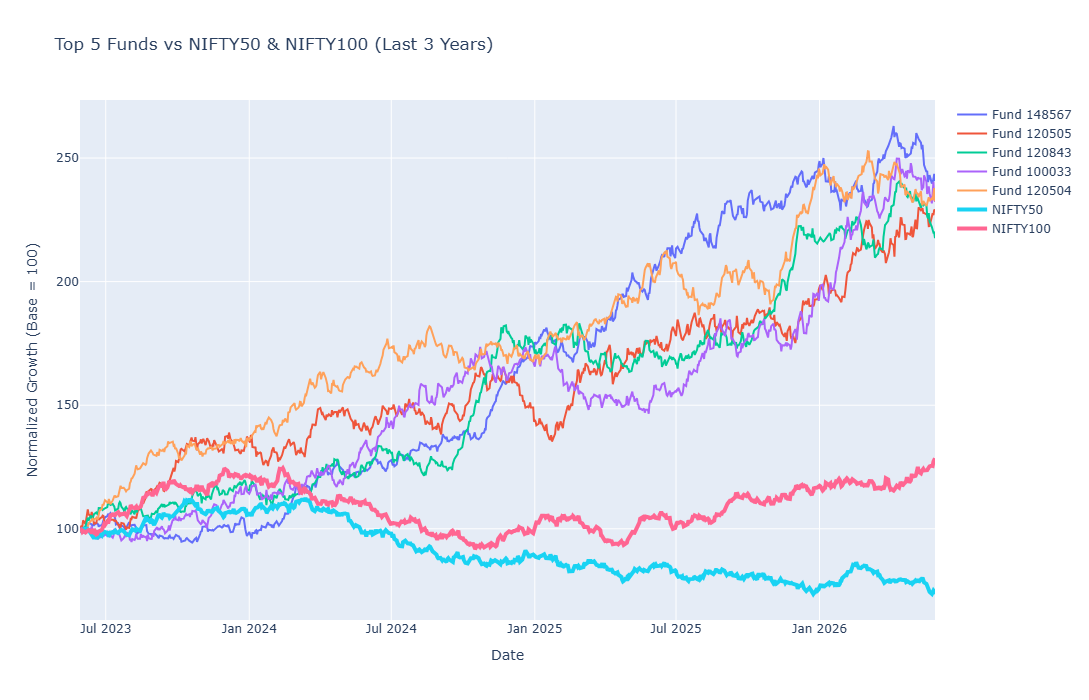

In [1]:
import pandas as pd
import plotly.graph_objects as go

nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

benchmark = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Top 5 funds
top5 = (
    scorecard
    .sort_values("fund_score", ascending=False)
    .head(5)["amfi_code"]
)

# Last 3 years
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nav = nav[
    nav["date"] >= start_date
]

benchmark = benchmark[
    benchmark["date"] >= start_date
]

fig = go.Figure()

# Top 5 funds
for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["normalized"] = (
        temp["nav"]
        / temp["nav"].iloc[0]
    ) * 100

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            mode="lines",
            name=f"Fund {fund}"
        )
    )

# NIFTY50
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["normalized"],
        mode="lines",
        name="NIFTY50",
        line=dict(width=4)
    )
)

# NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["normalized"],
        mode="lines",
        name="NIFTY100",
        line=dict(width=4)
    )
)

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)",
    xaxis_title="Date",
    yaxis_title="Normalized Growth (Base = 100)",
    height=700
)

fig.write_image(
    "../reports/charts/benchmark_chart.png"
)

fig.show()

In [2]:
import pandas as pd
import numpy as np

returns = pd.read_csv(
    "../data/processed/returns_computed.csv"
)

returns["date"] = pd.to_datetime(
    returns["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

tracking_error = []

for fund in top5:

    fund_returns = returns[
        returns["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date"
    ).dropna()

    te = (
        merged["daily_return"]
        - merged["benchmark_return"]
    ).std() * np.sqrt(252)

    tracking_error.append(
        [fund, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

tracking_error_df

,amfi_code,tracking_error
0,148567,0.187974
1,120505,0.232661
2,120843,0.206540
3,100033,0.224976
4,120504,0.187299
